<a href="https://colab.research.google.com/github/mtzwyu/TTNT/blob/main/Kmean/BTTL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Thuật toán đã hội tụ sau 6 vòng lặp.


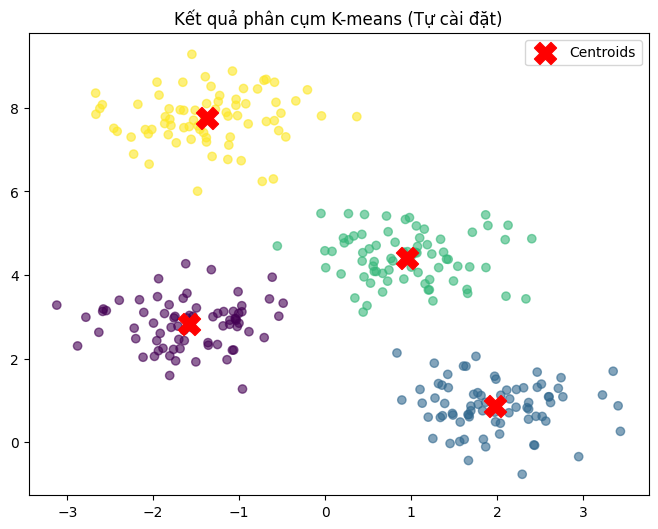

In [3]:
import numpy as np

class KMeans_Custom:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        """
        Khởi tạo mô hình K-means
        :param k: Số lượng cụm (clusters)
        :param max_iters: Số vòng lặp tối đa
        :param tol: Ngưỡng hội tụ (tolerance), dừng nếu centroids thay đổi ít hơn tol
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels_ = None

    def fit(self, X):
        # 1. Khởi tạo ngẫu nhiên k centroids từ các điểm dữ liệu X
        np.random.seed(42) # Set seed để kết quả ổn định khi test
        random_indices = np.random.permutation(X.shape[0])
        self.centroids = X[random_indices[:self.k]]

        for i in range(self.max_iters):
            # 2. Gán các điểm vào cụm có centroid gần nhất
            labels = self._assign_clusters(X)

            # Lưu lại centroids cũ để kiểm tra điều kiện dừng
            old_centroids = self.centroids.copy()

            # 3. Cập nhật lại vị trí các centroids
            self._update_centroids(X, labels)

            # 4. Kiểm tra hội tụ (Tính khoảng cách Euclidean giữa centroids cũ và mới)
            diff = np.linalg.norm(self.centroids - old_centroids)
            if diff < self.tol:
                print(f"Thuật toán đã hội tụ sau {i+1} vòng lặp.")
                break

        self.labels_ = self._assign_clusters(X)
        return self

    def _assign_clusters(self, X):
        # Tính khoảng cách từ mỗi điểm đến k centroids
        # X[:, np.newaxis] giúp broadcast X để tính toán song song với self.centroids
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)

        # Trả về index của centroid có khoảng cách nhỏ nhất cho mỗi điểm
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        for c in range(self.k):
            # Lấy tất cả các điểm dữ liệu thuộc cụm c
            cluster_points = X[labels == c]

            # Tính trung bình (mean) của các điểm để làm centroid mới
            if len(cluster_points) > 0:
                self.centroids[c] = np.mean(cluster_points, axis=0)

    def predict(self, X):
        # Dự đoán cụm cho dữ liệu mới
        return self._assign_clusters(X)

if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from sklearn.datasets import make_blobs

    # Tạo dữ liệu giả lập gồm 300 điểm, chia làm 4 cụm
    X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

    # Khởi tạo và huấn luyện mô hình tự cài đặt
    kmeans = KMeans_Custom(k=4, max_iters=100)
    kmeans.fit(X)

    # Trực quan hóa dữ liệu và các tâm cụm
    plt.figure(figsize=(8, 6))

    # Vẽ các điểm dữ liệu
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', marker='o', alpha=0.6)

    # Vẽ các tâm cụm (Centroids)
    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
                s=250, c='red', marker='X', label='Centroids')

    plt.title("Kết quả phân cụm K-means (Tự cài đặt)")
    plt.legend()
    plt.show()

In [5]:
import numpy as np
from collections import Counter

class KNN_Custom:
    def __init__(self, k=3, weights='uniform'):
        """
        Khởi tạo mô hình K-NN
        :param k: Số lượng điểm lân cận cần xét
        :param weights: Cách đánh giá trọng số ('uniform' hoặc 'distance')
        """
        self.k = k
        self.weights = weights
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Huấn luyện mô hình (Với k-NN, chỉ cần lưu lại tập dữ liệu huấn luyện)
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def predict(self, X):
        """
        Dự đoán nhãn cho tập dữ liệu mới
        """
        X = np.array(X)
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        """
        Dự đoán nhãn cho một điểm dữ liệu duy nhất
        """
        # 1. Tính khoảng cách Euclidean từ điểm x đến tất cả các điểm trong tập train
        distances = np.linalg.norm(self.X_train - x, axis=1)

        # 2. Lấy index của k điểm có khoảng cách nhỏ nhất
        k_indices = np.argsort(distances)[:self.k]

        # 3. Lấy nhãn của k điểm lân cận đó
        k_nearest_labels = self.y_train[k_indices]

        # 4. Đánh giá trọng số và đưa ra quyết định
        if self.weights == 'uniform':
            # Trọng số đồng đều: Chọn nhãn xuất hiện nhiều nhất (Majority vote)
            most_common = Counter(k_nearest_labels).most_common(1)
            return most_common[0][0]

        elif self.weights == 'distance':
            # Trọng số theo khoảng cách: w = 1 / distance
            k_distances = distances[k_indices]

            # Thêm một epsilon nhỏ (1e-10) để tránh lỗi ZeroDivisionError nếu distance = 0
            weights = 1.0 / (k_distances + 1e-10)

            # Tính tổng trọng số cho từng nhãn
            class_weights = {}
            for label, weight in zip(k_nearest_labels, weights):
                class_weights[label] = class_weights.get(label, 0) + weight

            # Trả về nhãn có tổng trọng số lớn nhất
            return max(class_weights, key=class_weights.get)

        else:
            raise ValueError("Tham số weights chỉ nhận 'uniform' hoặc 'distance'")


if __name__ == "__main__":
    from sklearn.datasets import load_iris
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score

    # Tải tập dữ liệu Iris (Bài toán phân loại hoa)
    data = load_iris()
    X = data.data
    y = data.target

    # Chia tập train/test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 1. Khởi tạo và test k-NN với trọng số ĐỒNG ĐỀU (Uniform)
    knn_uniform = KNN_Custom(k=5, weights='uniform')
    knn_uniform.fit(X_train, y_train)
    y_pred_uniform = knn_uniform.predict(X_test)
    acc_uniform = accuracy_score(y_test, y_pred_uniform)
    print(f"Độ chính xác k-NN (Uniform weights): {acc_uniform * 100:.2f}%")

    # 2. Khởi tạo và test k-NN với trọng số KHOẢNG CÁCH (Distance)
    knn_distance = KNN_Custom(k=5, weights='distance')
    knn_distance.fit(X_train, y_train)
    y_pred_distance = knn_distance.predict(X_test)
    acc_distance = accuracy_score(y_test, y_pred_distance)
    print(f"Độ chính xác k-NN (Distance weights): {acc_distance * 100:.2f}%")

Độ chính xác k-NN (Uniform weights): 100.00%
Độ chính xác k-NN (Distance weights): 100.00%


In [11]:
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter

# ==========================================
# 1. CLASS K-MEANS
# ==========================================
class KMeans_Custom:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels_ = None

    def fit(self, X):
        np.random.seed(42)
        random_indices = np.random.permutation(X.shape[0])
        self.centroids = X[random_indices[:self.k]]
        for _ in range(self.max_iters):
            labels = self._assign_clusters(X)
            old_centroids = self.centroids.copy()
            self._update_centroids(X, labels)
            if np.linalg.norm(self.centroids - old_centroids) < self.tol:
                break
        self.labels_ = self._assign_clusters(X)
        return self

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        for c in range(self.k):
            cluster_points = X[labels == c]
            if len(cluster_points) > 0:
                self.centroids[c] = np.mean(cluster_points, axis=0)

# ==========================================
# 2. CLASS K-NN
# ==========================================
class KNN_Custom:
    def __init__(self, k=3, weights='uniform'):
        self.k = k
        self.weights = weights

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self, x):
        distances = np.linalg.norm(self.X_train - x, axis=1)
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]

        if self.weights == 'uniform':
            most_common = Counter(k_nearest_labels).most_common(1)
            return most_common[0][0]
        elif self.weights == 'distance':
            k_distances = distances[k_indices]
            weights = 1.0 / (k_distances + 1e-10)
            class_weights = {}
            for label, weight in zip(k_nearest_labels, weights):
                class_weights[label] = class_weights.get(label, 0) + weight
            return max(class_weights, key=class_weights.get)

# ==========================================
# 3. GIAO DIỆN STREAMLIT
# ==========================================
st.set_page_config(page_title="Machine Learning Demo", layout="wide")
st.title("🎯 Ứng dụng Demo: K-Means & K-NN")

# Sidebar để tinh chỉnh thông số
st.sidebar.header("Cài đặt Thuật toán")
algorithm = st.sidebar.selectbox("Chọn thuật toán:", ("K-Means (Phân cụm)", "K-NN (Phân loại)"))

if algorithm == "K-Means (Phân cụm)":
    st.header("Thuật toán K-Means")

    # Tham số K-Means
    col1, col2 = st.columns(2)
    with col1:
        n_samples = st.slider("Số lượng điểm dữ liệu:", 100, 1000, 300)
        true_k = st.slider("Số cụm thực tế (sinh dữ liệu):", 2, 6, 4)
    with col2:
        k_param = st.slider("Số K (Tâm cụm dự đoán):", 2, 6, 3)
        max_iters = st.slider("Số vòng lặp tối đa:", 10, 200, 100)

    # Nút chạy
    if st.button("Chạy K-Means"):
        # Sinh dữ liệu
        X, y_true = make_blobs(n_samples=n_samples, centers=true_k, cluster_std=0.8, random_state=42)

        # Huấn luyện mô hình
        kmeans = KMeans_Custom(k=k_param, max_iters=max_iters)
        kmeans.fit(X)

        # Vẽ biểu đồ
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', marker='o', alpha=0.6)
        ax.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=300, c='red', marker='X', edgecolors='black', linewidths=2, label='Centroids')
        ax.set_title(f"Kết quả K-Means với k={k_param}")
        ax.legend()
        st.pyplot(fig)

elif algorithm == "K-NN (Phân loại)":
    st.header("Thuật toán K-Nearest Neighbors (K-NN)")

    # Tham số K-NN
    col1, col2 = st.columns(2)
    with col1:
        n_samples = st.slider("Số lượng điểm dữ liệu:", 100, 500, 200)
    with col2:
        k_neighbors = st.slider("Số lượng K lân cận:", 1, 15, 5)
        weight_method = st.radio("Cách tính trọng số:", ('uniform', 'distance'))

    if st.button("Chạy K-NN"):
        # Sinh dữ liệu phân loại 2 lớp đan xen nhau một chút
        X, y = make_classification(n_samples=n_samples, n_features=2, n_informative=2,
                                   n_redundant=0, n_clusters_per_class=1, random_state=42)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        # Huấn luyện mô hình
        knn = KNN_Custom(k=k_neighbors, weights=weight_method)
        knn.fit(X_train, y_train)

        # Dự đoán và tính accuracy
        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        st.success(f"Độ chính xác (Accuracy) trên tập Test: {acc * 100:.2f}%")

        # Vẽ biểu đồ Decision Boundary
        fig, ax = plt.subplots(figsize=(8, 6))

        # Tạo lưới để vẽ vùng quyết định (Decision Boundary)
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                             np.arange(y_min, y_max, 0.1))

        # Dự đoán trên toàn bộ lưới (có thể hơi chậm với pure python nên set step 0.1)
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = knn.predict(grid_points)
        Z = Z.reshape(xx.shape)

        # Vẽ vùng màu
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        # Vẽ các điểm Train
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', marker='o', label='Train data')
        # Vẽ các điểm Test
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolor='yellow', marker='^', s=100, label='Test data (Viền vàng)')

        ax.set_title(f"Ranh giới phân lớp K-NN (k={k_neighbors}, weights={weight_method})")
        ax.legend()
        st.pyplot(fig)

2026-05-19 12:00:43.317 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 12:00:43.320 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 12:00:43.322 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 12:00:43.324 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 12:00:43.327 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 12:00:43.328 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 12:00:43.330 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-19 12:00:43.332 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar